# Project 1: AI-Powered Fake News Detection Using Text Classification

This notebook implements a machine learning pipeline from scratch to classify news articles as real or fake, as outlined in the 30-Day Workflow.

## Data Loading & Cleaning

In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [13]:
# Load dataset
data = pd.read_csv("../Dataset/fake_news_dataset.csv")
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (1200, 14)


,id,title,full_text,source_name,publish_date,category,country,label,sentiment_score,clickbait_score,emotional_word_ratio,readability_score,source_trust_score,text_embedding
0,1,Official Report on Politics Development,As hoax a official of confirmed that report wi...,BBC,2024-10-08,Health,UK,0,0.1993,0.2196,0.1398,58.12,0.95,"[-0.06913215058559233, 0.13952064610006884, 0...."
1,2,Official Report on Entertainment Development,A university with illuminati the development t...,Reuters,2024-04-14,Entertainment,Australia,0,0.2266,0.1468,0.0832,74.75,0.98,"[0.21480910956629293, 0.10384384358155557, 0.1..."
2,3,Official Report on Politics Development,With conspiracy with development in analysis w...,CNN,2025-08-27,Business,USA,0,0.3985,0.0196,0.1231,55.67,0.88,"[-0.1355618005212844, 0.05082214384475504, -0...."
3,4,Official Report on Politics Development,To confirmed for scam of government a study a ...,BBC,2024-08-11,Health,Canada,0,0.0440,0.2596,0.0736,61.20,0.95,"[0.34673945595699684, -0.1960063199595648, 0.5..."
4,5,Official Report on Politics Development,Of secret it official it university the report...,CNN,2025-07-28,Health,Australia,0,0.0611,0.0301,0.0525,68.23,0.88,"[-0.37789575007918147, -0.5663345259384481, 0...."


In [14]:
# Handle missing values if any
data = data.dropna(subset=['full_text', 'label'])

# Feature and target selection (using 'full_text' as X and 'label' as y)
X = data['full_text']
y = data['label']

In [15]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'\W', ' ', text)  # remove punctuation
    text = text.lower()            # convert to lowercase
    return text

# Apply text cleaning
X = X.apply(clean_text)
print("Sample cleaned text:\n", X.iloc[0])

Sample cleaned text:
 as hoax a official of confirmed that report with policy a research as statement as university for study in development 


## Feature Engineering

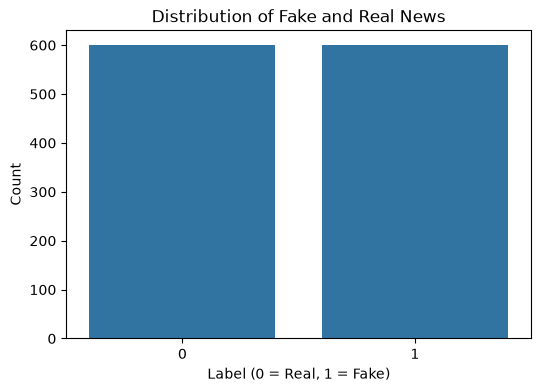

In [16]:
# Exploratory Data Analysis (EDA): Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribution of Fake and Real News")
plt.xlabel("Label (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_vec = vectorizer.fit_transform(X)

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (960, 25)
Test data shape: (240, 25)


## Model Building
Build models (KNN, Logistic Regression, Random Forest, Neural Net).

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Initialize models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Neural Net": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

## Model Evaluation


Training & Evaluating: KNN
Accuracy: 0.9750

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       122
           1       0.98      0.97      0.97       118

    accuracy                           0.97       240
   macro avg       0.98      0.97      0.97       240
weighted avg       0.98      0.97      0.97       240



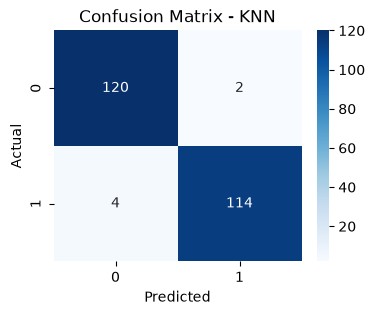


Training & Evaluating: Logistic Regression
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00       118

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



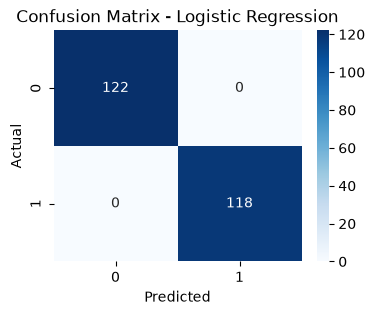


Training & Evaluating: Random Forest
Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       122
           1       0.98      0.95      0.97       118

    accuracy                           0.97       240
   macro avg       0.97      0.97      0.97       240
weighted avg       0.97      0.97      0.97       240



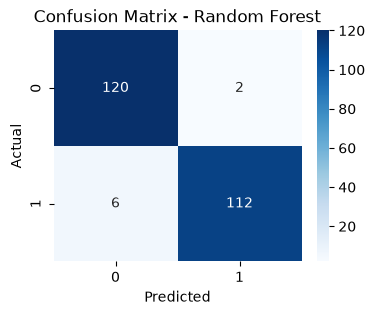


Training & Evaluating: Neural Net
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00       118

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



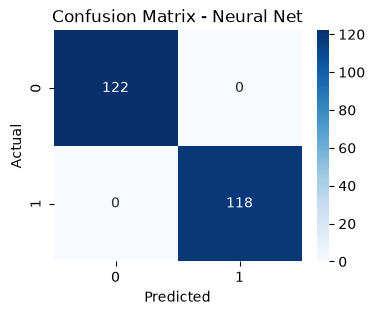

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training & Evaluating: {name}")
    print(f"{'='*50}")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions
    preds = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, preds))
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

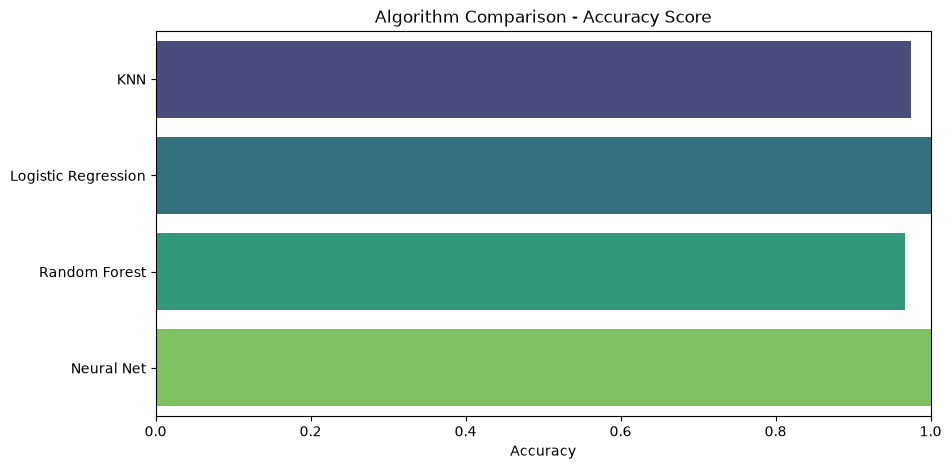

In [20]:
# Final Comparison Plot
plt.figure(figsize=(10, 5))
sns.barplot(y=list(results.keys()), x=list(results.values()), hue=list(results.keys()), palette="viridis")
plt.title('Algorithm Comparison - Accuracy Score')
plt.xlabel('Accuracy')
plt.xlim(0, 1.0)
plt.show()